In [ ]:
# pip install xgboost matplotlib pandas scikit-learn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib
import os

# Cấu hình hiển thị
%matplotlib inline

# ==========================================
# CẤU HÌNH
# ==========================================
INPUT_FILE = "../../data/processed/train_data_ready.csv"
MODEL_FILE = "../../model/xgboost_model.pkl"

TARGET_COL = "Gold"
SHIFT_STEPS = 1  # Dự báo giờ tiếp theo

print(f"✅ Đã import XGBoost version: {xgb.__version__}")

✅ Đã import XGBoost version: 3.1.2


In [2]:
# 1. Đọc dữ liệu
if not os.path.exists(INPUT_FILE):
    print(f"❌ Lỗi: Không thấy file {INPUT_FILE}")
else:
    df = pd.read_csv(INPUT_FILE)
    
    # Bỏ cột Datetime
    if 'Datetime' in df.columns:
        df = df.drop(columns=['Datetime'])

    # 2. Tạo cột Target (Giá tương lai)
    # Dịch ngược cột Gold lên 1 dòng
    df['Target'] = df[TARGET_COL].shift(-SHIFT_STEPS)

    # Xóa dòng cuối bị NaN
    df.dropna(inplace=True)
    
    print(f"📂 Dữ liệu sẵn sàng cho XGBoost: {df.shape}")

📂 Dữ liệu sẵn sàng cho XGBoost: (7636, 12)


In [3]:
# 1. Tách Feature (X) và Target (y)
X = df.drop(columns=['Target'])
y = df['Target']

# 2. Chia theo thời gian (80/20)
split_idx = int(len(X) * 0.8)

X_train, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_val = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"📊 Train set: {X_train.shape}")
print(f"📊 Val set:   {X_val.shape}")

📊 Train set: (6108, 11)
📊 Val set:   (1528, 11)


In [4]:
print("🚀 Bắt đầu Training XGBoost...")

# Khởi tạo mô hình
# n_estimators: Số lượng cây (1000 cây)
# learning_rate: Tốc độ học (0.05 là mức an toàn, chậm mà chắc)
# max_depth: Độ sâu của cây (tránh để quá sâu sẽ bị học vẹt)
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,      # Mỗi cây chỉ nhìn 80% dữ liệu (chống overfitting)
    colsample_bytree=0.8, # Mỗi cây chỉ nhìn 80% đặc trưng
    early_stopping_rounds=50, # Nếu 50 vòng không tiến bộ thì dừng
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1 # Dùng hết sức mạnh CPU
)

# Huấn luyện
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100 # In kết quả mỗi 100 vòng
)

print("✅ Training hoàn tất!")

# Lưu model
if not os.path.exists("model"):
    os.makedirs("model")
joblib.dump(model, MODEL_FILE)
print(f"💾 Đã lưu model tại {MODEL_FILE}")

🚀 Bắt đầu Training XGBoost...
[0]	validation_0-rmse:0.16715	validation_1-rmse:0.52939
[100]	validation_0-rmse:0.00317	validation_1-rmse:0.15066
[200]	validation_0-rmse:0.00257	validation_1-rmse:0.14957
[225]	validation_0-rmse:0.00249	validation_1-rmse:0.14989
✅ Training hoàn tất!
💾 Đã lưu model tại ../../model/xgboost_model.pkl


📉 Kết quả đánh giá XGBoost:
   - RMSE: 0.14942
   - MAE:  0.12686


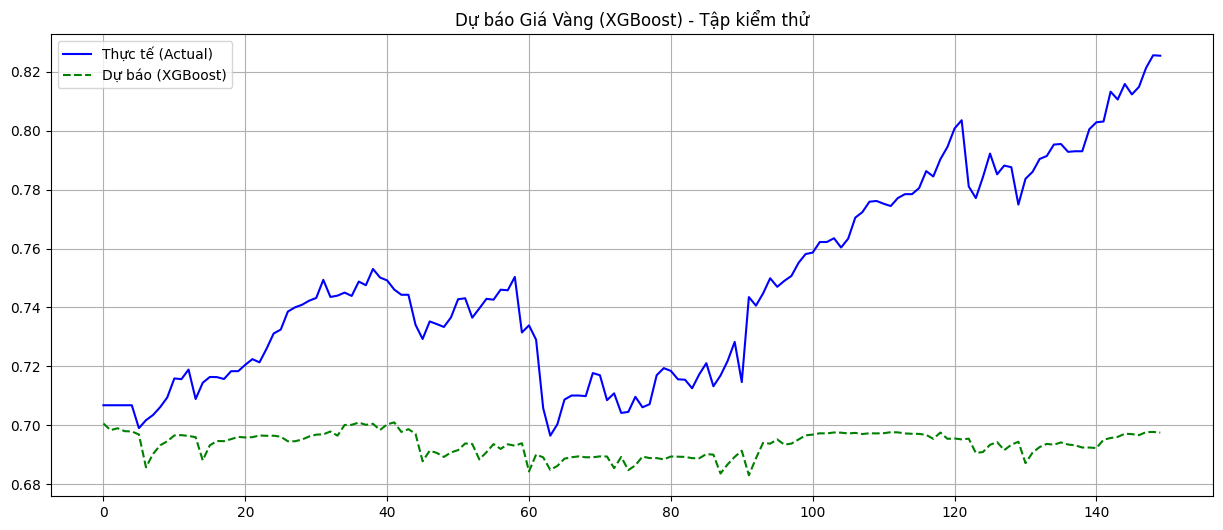

In [5]:
# 1. Dự báo
y_pred = model.predict(X_val)

# 2. Tính sai số
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae = mean_absolute_error(y_val, y_pred)

print(f"📉 Kết quả đánh giá XGBoost:")
print(f"   - RMSE: {rmse:.5f}")
print(f"   - MAE:  {mae:.5f}")

# 3. Vẽ biểu đồ so sánh (Zoom 150 điểm đầu)
plt.figure(figsize=(15, 6))
plt.plot(y_val.values[:150], label='Thực tế (Actual)', color='blue')
plt.plot(y_pred[:150], label='Dự báo (XGBoost)', color='green', linestyle='--')
plt.title('Dự báo Giá Vàng (XGBoost) - Tập kiểm thử')
plt.legend()
plt.grid(True)
plt.show()

<Figure size 1000x800 with 0 Axes>

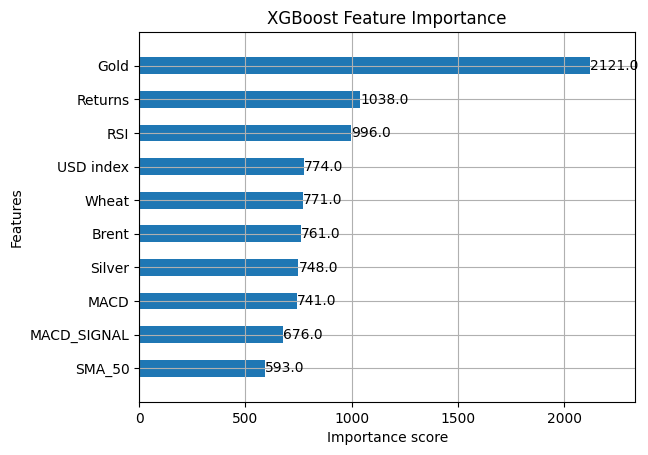

In [6]:
# Vẽ biểu đồ mức độ quan trọng của các biến
plt.figure(figsize=(10, 8))
xgb.plot_importance(model, max_num_features=10, height=0.5, title='XGBoost Feature Importance')
plt.show()